<a href="https://colab.research.google.com/github/chirusainanda/Data-Cleaning/blob/main/retail_bussiness_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import sqlite3
conn = sqlite3.connect("superstore.db")

In [2]:
import pandas as pd
import sqlite3
conn = sqlite3.connect("superstore.db")
conn.close()
print("\nDatabase saved successfully!")


Database saved successfully!


In [3]:
import pandas as pd
import sqlite3

# Load data back from database
conn = sqlite3.connect("superstore.db")
conn.close()

In [4]:
from google.colab import files
uploaded = files.upload()  # click and select your superstore.csv

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
pip install pandas seaborn matplotlib

In [7]:
import pandas as pd
import sqlite3
# Connect to SQLite
conn = sqlite3.connect("superstore.db")
print("\nFirst 5 rows:")


First 5 rows:


In [8]:
# =============================================
# FULL CLEAN SETUP - paste this in one cell
# =============================================
import pandas as pd
import sqlite3
# Connect
conn = sqlite3.connect("superstore.db")
print("\nCleaning done!")


Cleaning done!


In [9]:
from google.colab import files
uploaded = files.upload()   # select superstore.csv from your computer

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [10]:
import pandas as pd
import sqlite3
# Connect to database
conn = sqlite3.connect("superstore.db")
print("\nCleaning done!")


Cleaning done!


In [11]:
from google.colab import files
import pandas as pd
import sqlite3

# Step 1 - Upload CSV
uploaded = files.upload()   # select superstore.csv
# Step 4 - Recreate database
conn = sqlite3.connect("superstore.db")
# Step 5 - Verify table exists
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in database:", tables)
print("Database ready!")

Saving Sample - Superstore.csv to Sample - Superstore (2).csv
Tables in database: Empty DataFrame
Columns: [name]
Index: []
Database ready!


In [12]:
from google.colab import files
import pandas as pd
import sqlite3

# Step 1 - Upload CSV
uploaded = files.upload()   # select your Sample - Superstore.csv

# Step 2 - Load CSV (exact filename with spaces)
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")
print("CSV loaded! Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Step 3 - Clean data
df.dropna(subset=["Sales", "Profit"], inplace=True)
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"]  = pd.to_datetime(df["Ship Date"])
print("Cleaning done! Rows:", len(df))

# Step 4 - Create database and save table
conn = sqlite3.connect("superstore.db")
df.to_sql("orders", conn, if_exists="replace", index=False)
print("Data saved to database!")

# Step 5 - Verify table exists
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in database:", tables)

# Step 6 - Quick check
count = pd.read_sql("SELECT COUNT(*) AS total FROM orders", conn)
print("Total rows in orders table:", count)
print("\nDatabase ready!")

Saving Sample - Superstore.csv to Sample - Superstore (3).csv
CSV loaded! Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Cleaning done! Rows: 9994
Data saved to database!
Tables in database:      name
0  orders
Total rows in orders table:    total
0   9994

Database ready!


In [13]:
# Query 1 - Category profit margin
query1 = """
SELECT Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(SUM(Profit)*100.0/SUM(Sales), 2) AS Profit_Margin_Pct
FROM orders
GROUP BY Category
ORDER BY Profit_Margin_Pct DESC
"""
category_df = pd.read_sql(query1, conn)
print("CATEGORY PROFIT MARGIN:")
print(category_df)
print()

# Query 2 - Worst sub-categories
query2 = """
SELECT Sub_Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(SUM(Profit)*100.0/SUM(Sales), 2) AS Profit_Margin_Pct
FROM orders
GROUP BY Sub_Category
ORDER BY Profit_Margin_Pct ASC
"""
print("SUB-CATEGORY PROFIT MARGIN (worst first):")
print()

# Query 3 - Region wise performance
query3 = """
SELECT Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Order_Count
FROM orders
GROUP BY Region
ORDER BY Total_Profit DESC
"""
region_df = pd.read_sql(query3, conn)
print("REGION WISE PERFORMANCE:")
print(region_df)
print()

# Query 4 - Monthly trend
query4 = """
SELECT strftime('%Y-%m', "Order Date") AS Month,
    ROUND(SUM(Sales), 2) AS Monthly_Sales,
    ROUND(SUM(Profit), 2) AS Monthly_Profit
FROM orders
GROUP BY Month
ORDER BY Month
"""
monthly_df = pd.read_sql(query4, conn)
print("MONTHLY TREND:")
print(monthly_df)

CATEGORY PROFIT MARGIN:
          Category  Total_Sales  Total_Profit  Profit_Margin_Pct
0       Technology    836154.03     145454.95              17.40
1  Office Supplies    719047.03     122490.80              17.04
2        Furniture    741999.80      18451.27               2.49

SUB-CATEGORY PROFIT MARGIN (worst first):

REGION WISE PERFORMANCE:
    Region  Total_Sales  Total_Profit  Order_Count
0     West    725457.82     108418.45         1611
1     East    678781.24      91522.78         1401
2    South    391721.91      46749.43          822
3  Central    501239.89      39706.36         1175

MONTHLY TREND:
      Month  Monthly_Sales  Monthly_Profit
0   2014-01       14236.90         2450.19
1   2014-02        4519.89          862.31
2   2014-03       55691.01          498.73
3   2014-04       28295.35         3488.84
4   2014-05       23648.29         2738.71
5   2014-06       34595.13         4976.52
6   2014-07       33946.39         -841.48
7   2014-08       27909.47      

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_profit = df.groupby("Category")["Profit"].sum().reset_index()
print(cat_profit)

          Category       Profit
0        Furniture   18451.2728
1  Office Supplies  122490.8008
2       Technology  145454.9481


/tmp/ipykernel_4109/536377858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_profit, x="Category", y="Profit", palette="viridis")


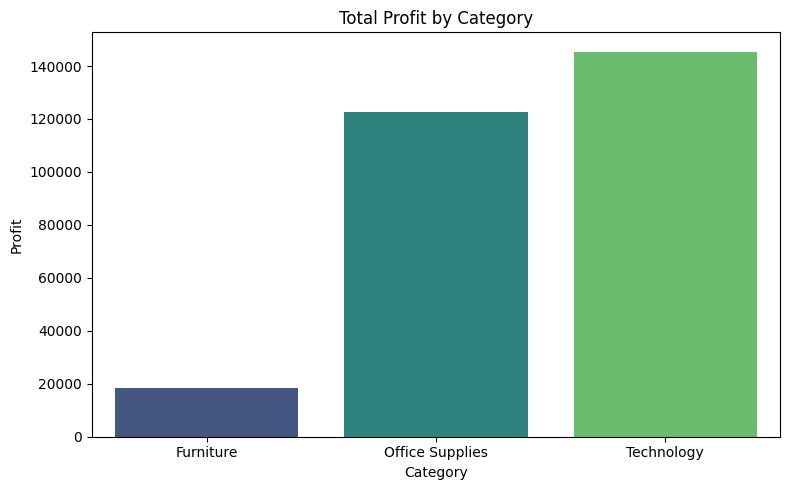

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cat_profit, x="Category", y="Profit", palette="viridis")
plt.title("Total Profit by Category")
plt.tight_layout()
plt.savefig("category_profit.png", dpi=150)
plt.show()

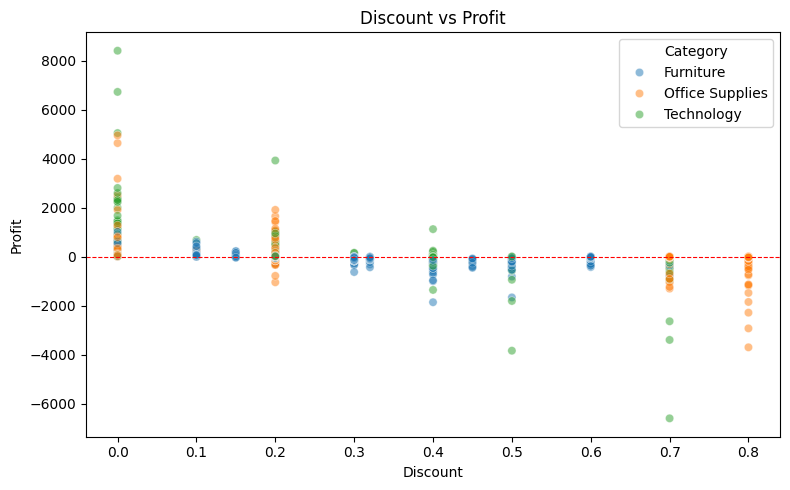

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category", alpha=0.5)
plt.title("Discount vs Profit")
plt.axhline(0, color="red", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig("discount_vs_profit.png", dpi=150)
plt.show()

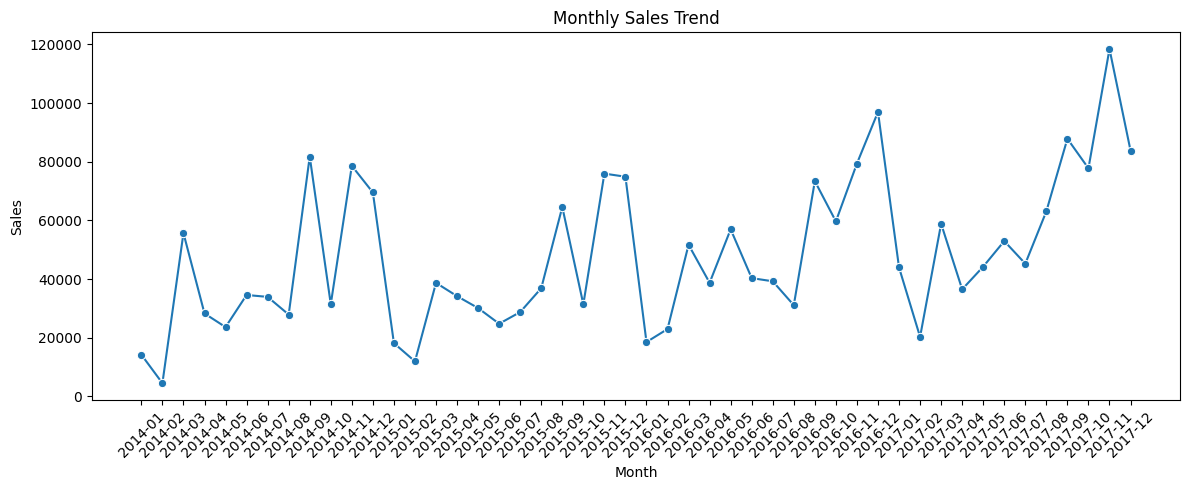

In [17]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)
monthly = df.groupby("Month")["Sales"].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x="Month", y="Sales", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=150)
plt.show()

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
import os

print(os.listdir('/content/drive/MyDrive'))

['com.feralinteractive.gridautosport_edition_android', 'IENT2002___ENTREPRENEURSHIP_copy.pdf', 'IENT2002___ENTREPRENEURSHIP_2_copy.pdf', 'IENT2001___ENTREPRENEURSHIP_copy (1).pdf', 'IENT2001___ENTREPRENEURSHIP_copy.pdf', 'IENT2001___ENTREPRENEURSHIP_3_copy.pdf', 'IENT2001 - ENTREPRENEURSHIP_copy (1).pdf', 'IENT2001 - ENTREPRENEURSHIP_copy.pdf', 'MBG302 - ENTREPRENEURSHIP_copy (1).pdf', 'MBG302 - ENTREPRENEURSHIP_copy.pdf', 'Give the common and important questions and answe....gsheet', 'Give the cmmon important  questions and answers... (3).gsheet', 'Give the cmmon important  questions and answers... (2).gsheet', 'Give the cmmon important  questions and answers... (1).gsheet', 'Give the cmmon important  questions and answers....gsheet', 'CSEN2041___FORMAL_LANGUAGES_AND_AUTOMATA_THEORY_copy.pdf', '19ECB201___FORMAL_LANGUAGE___AUTOMATA_THEORY_copy.pdf', 'CSEN2041 - FORMAL LANGUAGES AND AUTOMATA THEORY_copy.pdf', '19ECB201 - FORMAL LANGUAGE AND AUTOMATA THEORY_copy (1).pdf', '19ECS303 - FO

In [21]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'cleaned' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/cleaned_sales_data_v2.csv
/content/drive/MyDrive/cleaned_sales_data.csv


In [22]:
import pandas as pd
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ... Region  \
0      Claire Gute   Consumer  United States        Henderson  ...  South   
1      Claire Gute   Consumer  United States        Henderson  ...  South   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   West   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   

        Product ID         Category Sub-Category  \
0  FUR-BO-

In [23]:
index="Sub_Category"

In [24]:
df.rename(columns={"Sub-Category": "Sub_Category"}, inplace=True)

In [26]:
pivot = df.pivot_table(
    values="Profit",
    index="Sub_Category",
    columns="Region",
    aggfunc="sum"
)

In [27]:
pivot = pivot.fillna(0)

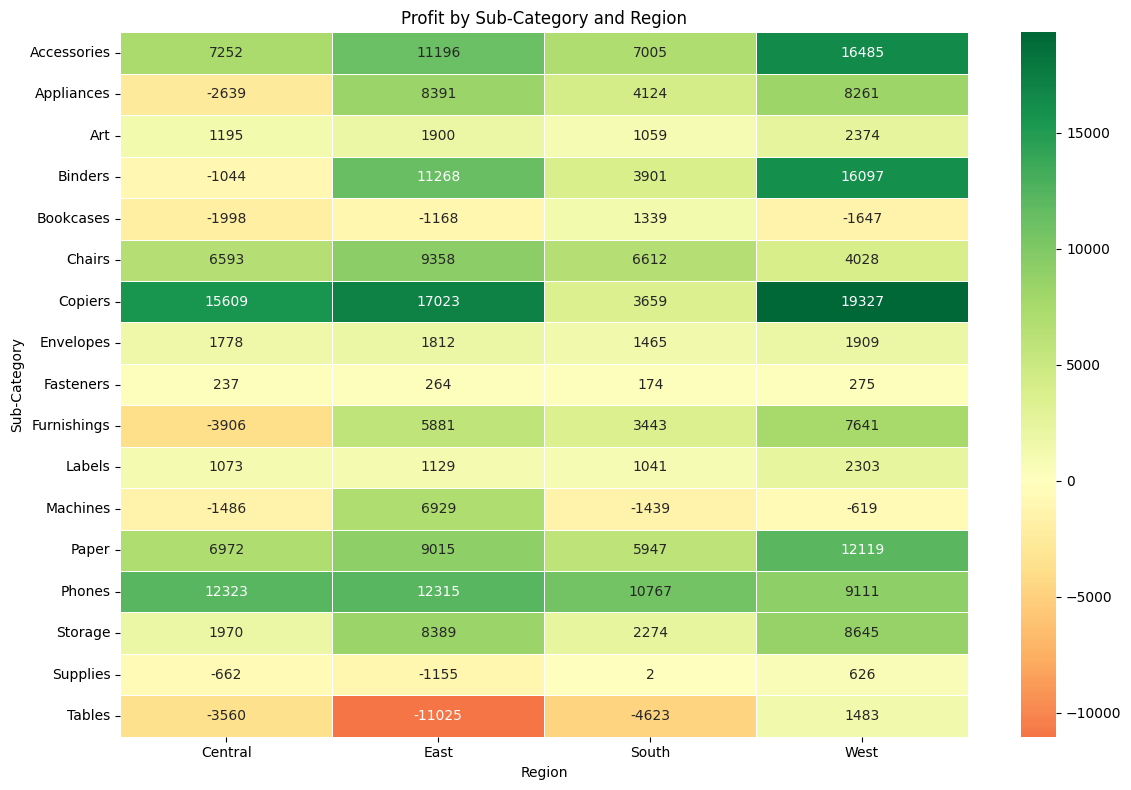

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title("Profit by Sub-Category and Region")
plt.xlabel("Region")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

In [29]:
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [30]:
plt.show()

In [31]:
plt.savefig("/content/heatmap.png", dpi=150)

<Figure size 640x480 with 0 Axes>

In [32]:
plt.figure(figsize=(12, 8))

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn", center=0)

plt.title("Profit by Sub-Category and Region")

plt.tight_layout()

plt.savefig("/content/heatmap.png", dpi=150)
plt.close()   # 🔥 THIS prevents duplicate display

In [41]:
plt.close()

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


project-1 complete